# Unit I: Climate Change Module

## Reproducing the hockey stick, and checking whether we got it right

Our target is the result reported by [Mann et al (1998)](https://doi.org/10.1038/33859): that
recent warming stands outside the range of natural variability over the past several centuries.
You will rebuild that picture from current observations and ice-core records, in the style of
NASA's [vital signs](https://climate.nasa.gov/vital-signs).

A language model will write most of the parsing code. It is good at it, and it is also wrong in
ways that run cleanly and produce a plot. Your job is the question scientists have always had to
answer about code they did not write:

> **How do I know these numbers are right?**

Each part below gives you a data source and a question. It does not tell you what is wrong with
the data. Finding that out is the assignment.

## Rules of engagement

- **Plan mode only.** You review and approve the plan before any code runs.
- **Keep your prompts.** Record what you asked for. The prompt is part of your method.
- **Never report a number you have not checked.** Unverified or fabricated data is the one
  automatic-failure condition in this module, and it is no less serious because a model produced
  it.

Setup, GitHub authentication, and model configuration are on the
[course website](https://espm-157.carlboettiger.info/).

### Verification block

Every dataset gets these five questions answered, in your own words, **before** you plot it.
Each part below ends with one.

1. **Extent** — how many rows, what time range, and does that match the source documentation?
2. **Missing data** — how is it encoded, and did your parser catch it?
3. **Units** — what are they, and where in the source is that stated?
4. **Completeness** — the whole dataset, or one piece of it?
5. **Cross-check** — one value confirmed against an independent source.

---

# Part 1: The code you didn't write

Mauna Loa monthly CO2: <https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt>

Below is working code for that file. It runs and it produces a plausible plot.

In [1]:
import pandas as pd
from plotnine import *

In [2]:
columns = ['year', 'month', 'decimal_date', 'average', 'smooth', 'std_days', 'uncertainty', 'empty']
df = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt",
                  sep = '\\s+',
                  comment = '#',
                  header = None,
                  names = columns
                  )
df

,year,month,decimal_date,average,smooth,std_days,uncertainty,empty
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26


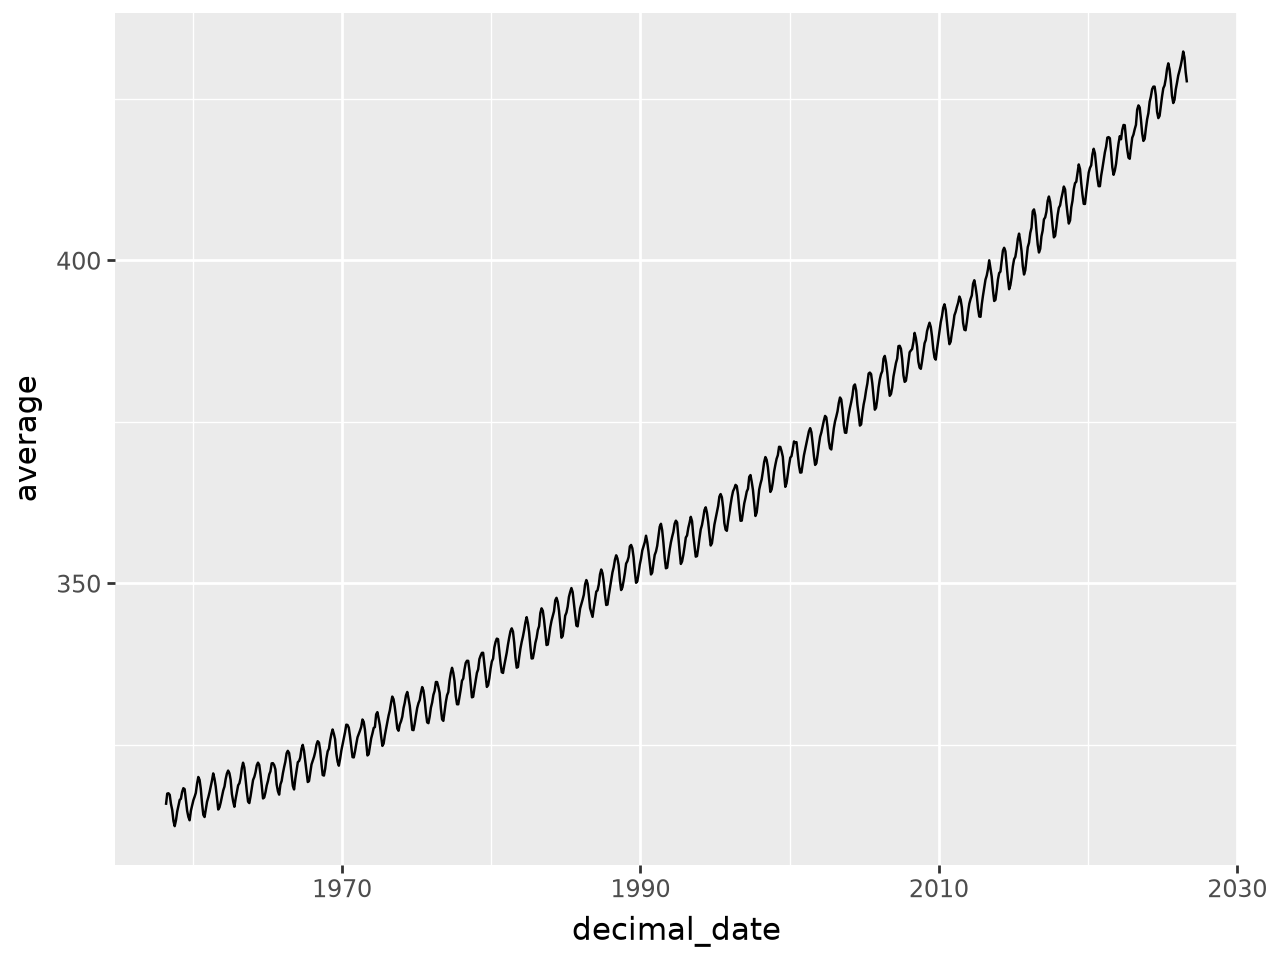

In [3]:
ggplot(df, aes(x="decimal_date", y="average")) + geom_line()

### Task 1.1: Read the source, not the code

That `columns` list was written by hand. Open the raw file and read its header block, then check
every name against what the header says the column holds. Report any that misstate it, and say
which of those would change a published figure if nobody noticed. Hello

**Your answer:** The "#days" column in the raw file, as well as the deseasonalized, the standard deviation of days, and uncertainty of monthly mean columns are mislabeled in our table. None of these would affect our figure as it used the decimal date and monthly average to construct itself.  

### Task 1.2: Missing values

How does this file encode a measurement that was not made? Verify it in the raw file, count the
affected rows per column, and say what a naive `mean()`, `min()`, or error bar would report if you
left them in. State what you did about it and why.

In [4]:
missing_months = df["uncertainty"] == -9.99
print(missing_months.sum())  
df[missing_months]     

196


,year,month,decimal_date,average,smooth,std_days,uncertainty,empty
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
191,1974,2,1974.1260,330.71,330.03,-1,-9.99,-0.99
192,1974,3,1974.2027,331.49,330.15,-1,-9.99,-0.99
193,1974,4,1974.2877,332.65,330.24,-1,-9.99,-0.99
213,1975,12,1975.9583,330.77,331.74,-1,-9.99,0.00


**Your answer:** The file encodes measurements that were not made by representing them with negative numbers. These numbers stand in for "blank data." The average is significantly influenced  by these measurements. To prevent these measurements from influencing our averages, we could omit these missing measuerements from our table entirely.

### Task 1.3: What the numeric columns cannot tell you

The header block contains prose notes as well as column definitions. Read them.

Does anything there change how you would plot or interpret this series? Show your evidence in the
data rather than asserting it, and say whether a model reading only the numeric columns would have
any way to know.

In [5]:
subset = df[(df["year"] >= 1973) & (df["year"] <= 1976)]

naive_unc = subset["uncertainty"].mean()                          # includes -0.99 / 0.00 flags
real_unc = subset.loc[subset["uncertainty"] > 0, "uncertainty"].mean()  # flags removed

print(f"Mean monthly average 1973-1976 : {subset['average'].mean():.2f} ppm")
print(f"Naive mean uncertainty         : {naive_unc:.2f}")
print(f"Mean uncertainty (flags removed): {real_unc:.2f}")
print(f"Months used for 'real' mean    : {(subset['uncertainty'] > 0).sum()} of {len(subset)}")

Mean monthly average 1973-1976 : 330.76 ppm
Naive mean uncertainty         : -3.27
Mean uncertainty (flags removed): 0.41
Months used for 'real' mean    : 31 of 48


**Your answer:** From our human perspectives, we can learn to ignore the negative values as we understand they don't really represent anyhting, especially if the monthly averages for those months are still recorded. However, computers have a harder time distinguishing things. We can see here that the average uncertainty from 1973 to 1976 would be -3.27 if the negative uncertainty values were incorporated into the calculations, which would mean nothing to us. However, we can specify with our agent to disregard thenegative values, giving us a "real" mean uncertainty of 0.41.

Monthly averages are also determined by the average of daily CO2 values measured in a given month. Some months have almost 30 days, while some have under 10. Therefore, when plotting, a model wouldn't be able to take that information into account when constructing a plot of monthly CO2 averages. This would be more clearly expressed if we had access to the exact days these CO2 measurements were taken, giving us a more accurate idea of CO2 values.

### Task 1.4: Check whether a better door exists

Before you fix a parser, find out whether you need one. NOAA distributes this same monthly record
in more than one format: <https://gml.noaa.gov/ccgg/trends/data.html>

Load an alternative distribution. Which of the problems you found above does switching formats
solve, and which does it not?

In [1]:
annual = pd.read_csv(
    "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_annmean_mlo.txt",
    sep=r"\s+",
    comment="#",
    header=None,
    names=["year", "mean", "unc"],
)

annual

NameError: name 'pd' is not defined

**Your answer:** While the annual mean data effectively disregards the uncertainty by standardizing the uncertainty to 0.12 throughout the data, it essentially makes the uncertainty value within that data useless. In the monthly mean data, we have a much clearer view of what the uncertainty is per month, but it can still be influenced by the missing month uncertainty values of -0.99.

### Task 1.5: The other library

Now try to load the original `.txt` with `ibis` instead of `pandas`. Report what happens.

Explain the result in terms of the *file*, not the library. What does it do to a rule like "always
use `ibis`"?

In [14]:
import ibis

t = ibis.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt")

**Your answer:** ibis expects data that has already been organized into a table. It doesn't work well when attempting to analyze a raw text file. "Always use ibis" only works when the data is already a table. Here, we want to organize a table, so ibis is useless.

### 🔍 Verification block 1

1. Extent:
2. Missing data:
3. Units:
4. Completeness:
5. Cross-check:

---

# Part 2: Arctic sea ice

National Snow and Ice Data Center, sea ice index G02135:

- Documentation: <https://nsidc.org/data/G02135>
- Data directory: <https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/>

### Task 2.1: Ask first, look second

Before opening that directory yourself, ask your model to load Arctic sea ice extent and plot the
trend. Let it produce a plan.

**Record the prompt you used:**

```
Load the Arctic sea ice extent from this data, then plot it: https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/
```

    year  mo source_dataset region  extent   area       date
0   1978  11     NSIDC-0051      N   11.65   9.04 1978-11-01
1   1978  12     NSIDC-0051      N   13.67  10.90 1978-12-01
2   1979   1     NSIDC-0051      N   15.41  12.41 1979-01-01
3   1979   2     NSIDC-0051      N   16.18  13.18 1979-02-01
4   1979   3     NSIDC-0051      N   16.34  13.21 1979-03-01
5   1979   4     NSIDC-0051      N   15.45  12.53 1979-04-01
6   1979   5     NSIDC-0051      N   13.86  11.11 1979-05-01
7   1979   6     NSIDC-0051      N   12.53   9.34 1979-06-01
8   1979   7     NSIDC-0051      N   10.31   6.69 1979-07-01
9   1979   8     NSIDC-0051      N    8.04   5.06 1979-08-01
10  1979   9     NSIDC-0051      N    7.05   4.58 1979-09-01
11  1979  10     NSIDC-0051      N    8.75   6.19 1979-10-01
12  1979  11     NSIDC-0051      N   10.94   8.37 1979-11-01
13  1979  12     NSIDC-0051      N   13.34  10.63 1979-12-01
14  1980   1     NSIDC-0051      N   14.86  11.94 1980-01-01
15  1980   2     NSIDC-0

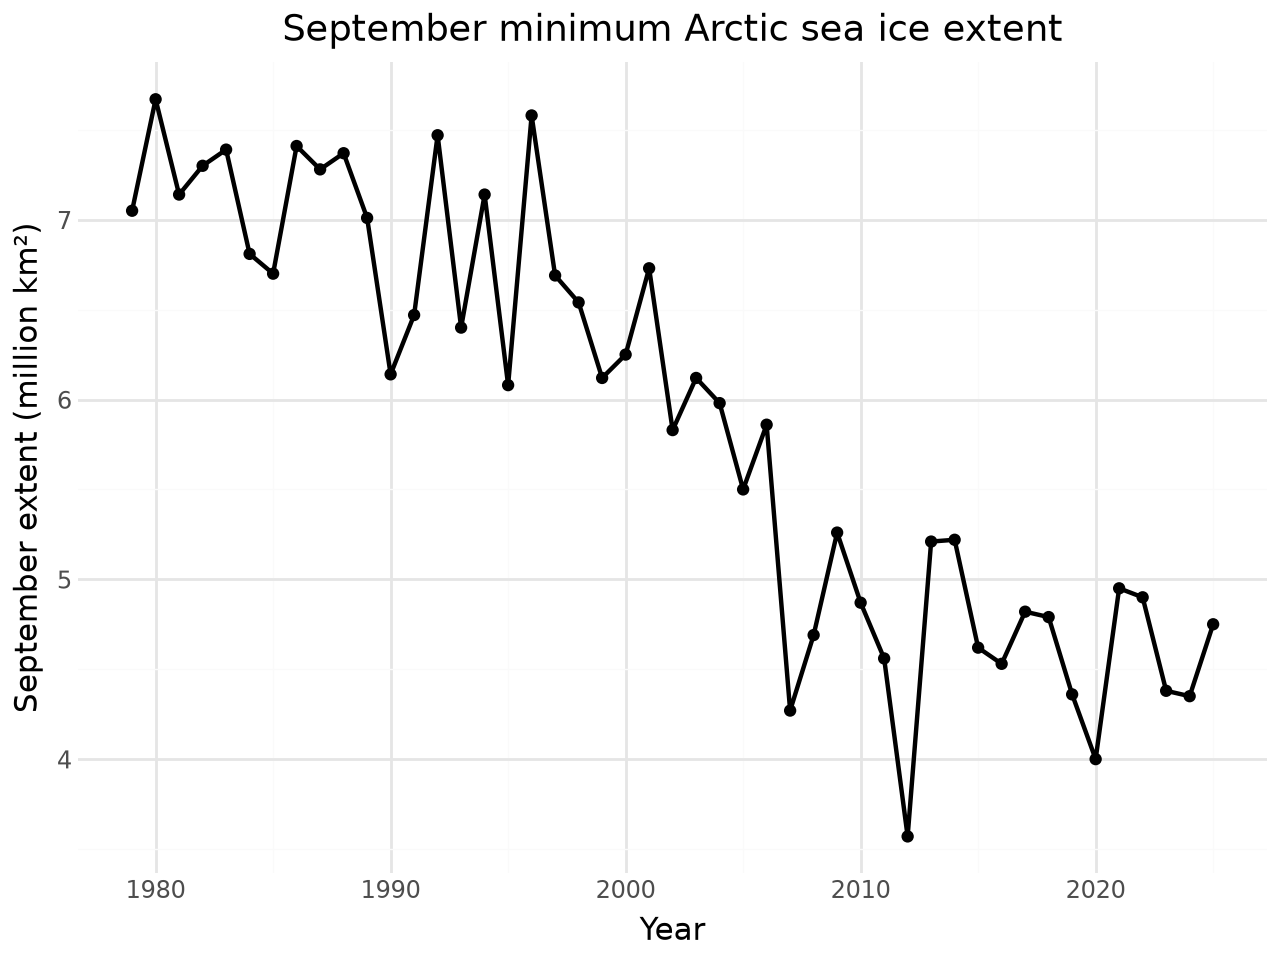

In [15]:
import pandas as pd
from plotnine import *

base = "https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/"

frames = []
for m in range(1, 13):
    url = f"{base}N_{m:02d}_extent_v4.0.csv"
    d = pd.read_csv(url, skipinitialspace=True)
    frames.append(d)

seaice = pd.concat(frames, ignore_index=True)

# Build a proper date index and sort chronologically
seaice["date"] = pd.to_datetime({"year": seaice["year"],
                                 "month": seaice["mo"],
                                 "day": 1})
seaice = seaice.sort_values("date").reset_index(drop=True)
print(seaice.head(20))
print("rows:", len(seaice), "| years:", seaice["year"].min(), "-", seaice["year"].max())

(ggplot(seaice, aes(x="date", y="extent", color="mo"))
 + geom_point(size=1.2, alpha=0.6)
 + labs(x="Date", y="Sea ice extent (million km²)",
        title="Arctic sea ice extent, monthly (G02135, north)")
 + theme_minimal())

(ggplot(seaice[seaice["mo"] == 9], aes(x="year", y="extent"))
 + geom_line(size=0.9)
 + geom_point(size=1.5)
 + labs(x="Year", y="September extent (million km²)",
        title="September minimum Arctic sea ice extent")
 + theme_minimal())

### Task 2.2: What did it actually load?

Now open the data directory and look at what is there.

Check the URL the model's code used against the directory listing *before* you run anything. Did
it point at a file that exists? If it ran, how much of the record does the plot actually show, and
is the title honest? If it failed, would you have predicted that failure from reading the code?

A model that has never seen this directory still has to produce a filename. Note where it got one.

**Your answer:** It did point at a file that exists and used September's monthly data to build a plot. It shows the entire record of Septmber's monthly ice extent values from 1979 to 2025.

### Task 2.3: Build the complete record

Load the full dataset and plot sea ice extent over time.

Then make a scientific decision and defend it: the September minimum is the standard index for
Arctic sea ice loss, and it is not the same thing as the annual mean. Which does your analysis
report, and why is that right for the question you are asking?

**Your answer:**

### 🔍 Verification block 2

1. Extent:
2. Missing data:
3. Units:
4. Completeness:
5. Cross-check:

---

# Part 3: Emissions by industry

[EXIOBASE](https://www.exiobase.eu/) is a multi-regional, environmentally-extended input-output
database: economic flows between industries and regions worldwide, with the emissions attached to
them. It lets you ask which *industries* drive emissions, not just which countries.

We use the cloud-optimized Parquet copy at
[source.coop/youssef-harby/exiobase-3](https://source.coop/youssef-harby/exiobase-3). The
inter-industry transaction table `Z` for one year:

```
https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet
```

### Task 3.1: Ask without guidance

Ask your model to compute total industrial output by origin region for 2022 from that file. Do not
tell it which library to use.

**Record the prompt you used:**

```
[paste your prompt here]
```

**Which library did it choose, unprompted?**

### Task 3.2: Measure what it cost

Run the code it wrote inside the harness below, which reports peak memory and wall time. Your
session has roughly **4 GB of RAM**. Report what happens, including if it does not finish.

In [ ]:
import resource, time, contextlib

@contextlib.contextmanager
def measure(label):
    t0 = time.time()
    try:
        yield
    finally:
        peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024**2
        print(f"{label}: peak memory {peak:.2f} GB, elapsed {time.time() - t0:.1f}s")

# with measure("pandas"):
#     result = ...

### Task 3.3: Now constrain it

Ask again, this time requiring `ibis` with the DuckDB backend. Measure the same way.

| approach | peak memory | elapsed | did it finish? |
|---|---|---|---|
| unguided | | | |
| ibis / duckdb | | | |

**Do the two approaches give the same answer?** Check, do not assume. If they disagree, that is a
finding worth more than either number alone.

### Task 3.4: Why did it choose that?

Why does a model, asked to analyze data with no further guidance, reach for the library it
reached for? Consider what its training data looks like.

- What does it mean that the tool most likely to be *suggested* is the one most represented in
  code written years ago?
- On the evidence of this exercise, what is the human actually contributing?
- What would have happened if nobody in the room knew the alternative existed?
- In Task 1.5 you found the reverse case. State the rule that covers both, without naming a
  library.

**Your answer:**

---

# Part 4: Which CO2?

The `F_satellite` table holds the environmental extensions — emissions and resource flows attached
to each industry and region.

```
https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=F_satellite/data.parquet
```

### Task 4.1: Survey before you filter

Load the table. Before writing any filter, report how many distinct values the `stressor` column
contains, how many of them mention CO2 (with their units and totals), and how many distinct units
appear in the `unit` column across the whole table.

**Your answer:**

### Task 4.2: What did you just add together?

Group by region and sum `value` across all stressors. Then look at what that sum contains.

How many different units went into it? Is the result a mass, a volume, a currency, or a number
with no meaning? What is the ratio between the two most common units, and what would mixing them
do to a national total?

**Your answer:**

### Task 4.3: Choose your stressors, and defend the choice

Compute total CO2 emissions by region for 2022.

You must decide which stressors belong in that total. This is a scientific judgment, not a
string-matching exercise: filtering too narrowly omits real emissions, and matching every name
containing `"CO2"` includes flows that standard greenhouse-gas accounting deliberately excludes.
Find out which, and on what grounds.

Ask your model which to include, then check its reasoning against the accounting convention.

**Which stressors did you include, and why? Which did you exclude, and why?**

### Task 4.4: Reconcile against an independent source

Compare your EXIOBASE national totals against Our World in Data:
<https://github.com/owid/co2-data/raw/master/owid-co2-data.csv>

They will not match. Pick one country and quantify the gap:

| | value | units |
|---|---|---|
| OWID total | | |
| Your EXIOBASE total | | |
| Absolute difference | | |
| Relative difference | | |

Then explain it. The two sources do not measure the same thing — establish what each one actually
counts before you attribute the gap to anything. Candidates to test rather than assert: accounting
scope, gas coverage, sectoral boundaries, your stressor set from 4.3, and year alignment.

**A country that imports most of its manufactured goods should show a particular direction of gap.
Does yours? What does that tell you about the two accounting systems?**

**Your reconciliation:**

### 🔍 Verification block 3

1. Extent:
2. Missing data:
3. Units:
4. Completeness:
5. Cross-check:

---

# Part 5: The hockey stick

Instrumental records cover roughly the last century and a half. To judge whether recent change is
unusual you need a longer baseline, which means proxy records rather than thermometers.

**Vostok ice core**, back roughly 400,000 years:

- Description: <https://cdiac.ess-dive.lbl.gov/trends/co2/vostok.html>
- Data: <https://doi.org/10.3334/CDIAC/ATG.009>

### Task 5.1: Load the ice core record

Load it, and read its documentation carefully enough to say what its index actually is and how it
is sampled. Both bear on what you can legitimately plot next to a modern monthly series.

### Task 5.2: Put modern CO2 in geological context

Combine the Vostok record with the Mauna Loa series from Part 1 in a single figure.

Getting this figure to be *honest* is the hard part:

- The two series have very different sampling resolution. What does a shared axis imply that may
  not be true?
- Where do the records join, and are they measuring the same quantity the same way?
- What does the modern value look like against the full 400,000-year range?

### Task 5.3: Interpret

Relative to [Mann et al (1998)](https://doi.org/10.1038/33859):

- Does your reconstruction support the paper's central claim?
- Where does it differ, and why — more recent data, different proxies, different processing?
- What in your figure is a genuine finding, and what is an artifact of a choice you made?

**Your interpretation:**

---

# Part 6: Reflection

1. **Failure inventory.** List every case where the model produced code that ran without error but
   was wrong. What was wrong, and what tipped you off?
2. **Detection.** Which of those would you have caught from the plot alone? Which required going
   back to the source documentation?
3. **Division of labor.** What did you contribute that the model did not? If the answer for some
   task is "nothing", say so.
4. **Plan mode.** Where did approving the plan catch something? Where was it just friction?
5. **Tool choice.** You have now seen the same task done two ways, and data read locally versus
   streamed. What decides which is right, and who makes that decision?

**Your reflection:**

1.
2.
3.
4.
5.

---

## Submission

- [ ] Notebook runs top to bottom without errors
- [ ] All three verification blocks completed
- [ ] Prompts recorded where asked (Tasks 2.1, 3.1)
- [ ] Memory and timing table filled in (Task 3.3)
- [ ] Stressor selection defended (Task 4.3) and reconciliation quantified (Task 4.4)
- [ ] Hockey stick figure with the modern record in geological context (Task 5.2)
- [ ] Reflection complete (Part 6)
- [ ] README updated with team members, badge, and description
- [ ] Repository passes its GitHub Actions check

See [rubric.md](rubric.md) for scoring.